# Optimizing hyperparameters

This notebook was used to find the optimal time intervals for the BT-LDA versions

In [ ]:
# imports
import mne
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from toeplitzlda.classification import ToeplitzLDA
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import numpy as np
from tqdm import tqdm
import pickle

# utils functions
from utils.preprocessing import load_session_chached, merge_sessions
from utils.feature_extraction_v2 import epoch_vectorizer_channelprime
from cross_validation_functions import get_results_800ms_btlda, get_results_1000ms_btlda, get_results_800ms_slda

# Turn off warnings (that most likely occur from ToeplitzLDA)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')

### Time intervals: 0.1-0.8 in 50 ms steps

Grand average of 100 ms: 0.6717691143845225
Grand average of 50 ms: 0.6770681984194746
Grand average of 20 ms: 0.6712814620667906
Grand average of 10 ms: 0.6685915689516675


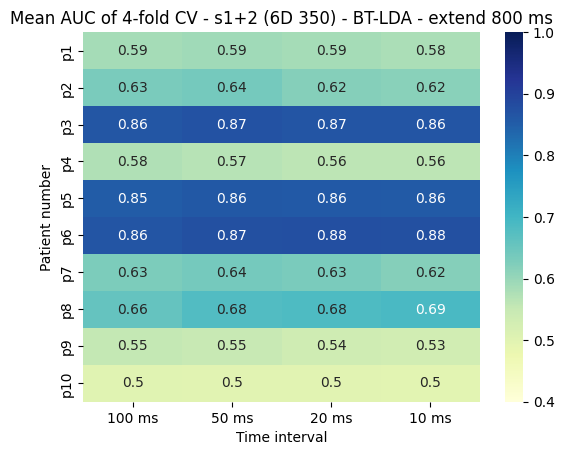

In [ ]:
# Results

# results = get_results_800ms_btlda() I have already run this and saved the results, so they can be loaded now
results = np.load('max_800_btlda_ivals_cv.npy', allow_pickle=True)
import seaborn as sns

# Histogram --------------------------------------

sns.heatmap(results,vmin=0.4,vmax=1,annot=True, yticklabels=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10'], cmap="YlGnBu", xticklabels=['100 ms', '50 ms', '20 ms', '10 ms'])
plt.ylabel("Patient number")
plt.xlabel("Time interval")
plt.title("Mean AUC of 4-fold CV - s1+2 (6D 350) - BT-LDA - extend 800 ms")

# Print results
#print(fold_means_array.shape)
print(f"Grand average of 100 ms: {np.mean(results, axis=0)[0]}")
print(f"Grand average of 50 ms: {np.mean(results, axis=0)[1]}")
print(f"Grand average of 20 ms: {np.mean(results, axis=0)[2]}")
print(f"Grand average of 10 ms: {np.mean(results, axis=0)[3]}")


### Extending interval even more: 0.1-1.0 in 50 ms steps

Grand average of 100 ms: 0.6746380279827305
Grand average of 50 ms: 0.6786270709069525
Grand average of 20 ms: 0.670995903108312
Grand average of 10 ms: 0.6677513515694777


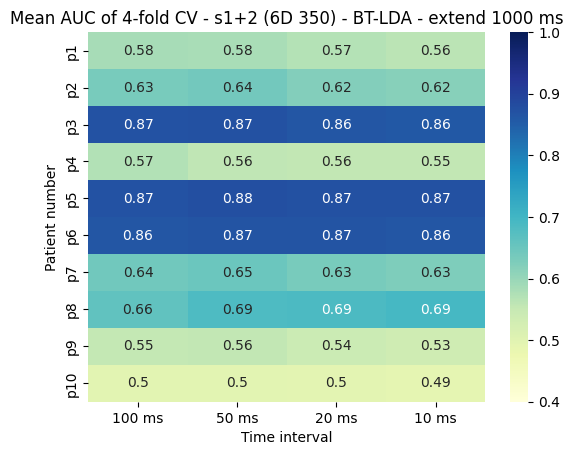

In [ ]:
# Results
# results = get_results_1000ms_btlda() I have already run this and saved the results, so they can be loaded now
results_1s = np.load('max_1000_btlda_ivals_cv.npy', allow_pickle=True)

import seaborn as sns

# Histogram --------------------------------------
sns.heatmap(results_1s,vmin=0.4,vmax=1,annot=True, yticklabels=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10'], cmap="YlGnBu", xticklabels=['100 ms', '50 ms', '20 ms', '10 ms'])
plt.ylabel("Patient number")
plt.xlabel("Time interval")
plt.title("Mean AUC of 4-fold CV - s1+2 (6D 350) - BT-LDA - extend 1000 ms")

# Print results
print(f"Grand average of 100 ms: {np.mean(results_1s, axis=0)[0]}")
print(f"Grand average of 50 ms: {np.mean(results_1s, axis=0)[1]}")
print(f"Grand average of 20 ms: {np.mean(results_1s, axis=0)[2]}")
print(f"Grand average of 10 ms: {np.mean(results_1s, axis=0)[3]}")

### Shrinkage LDA instead of BT-LDA

Grand average of 100 ms: 0.6702908720859402
Grand average of 50 ms: 0.6728198031587007
Grand average of 20 ms: 0.6659303825781742
Grand average of 10 ms: 0.6629866314079743


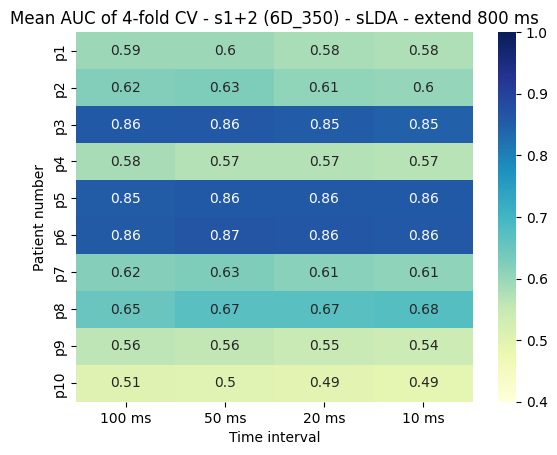

In [ ]:
# Results
# results = get_results_800ms_slda I have already run this and saved the results, so they can be loaded now
results = np.load('max_800_slda_ivals_cv.npy', allow_pickle=True)
import seaborn as sns

# Histogram 1 --------------------------------------
sns.heatmap(results,vmin=0.4,vmax=1,annot=True, yticklabels=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10'], cmap="YlGnBu", xticklabels=['100 ms', '50 ms', '20 ms', '10 ms'])
plt.ylabel("Patient number")
plt.xlabel("Time interval")
plt.title("Mean AUC of 4-fold CV - s1+2 (6D_350) - sLDA - extend 800 ms")

# Print results
print(f"Grand average of 100 ms: {np.mean(results, axis=0)[0]}")
print(f"Grand average of 50 ms: {np.mean(results, axis=0)[1]}")
print(f"Grand average of 20 ms: {np.mean(results, axis=0)[2]}")
print(f"Grand average of 10 ms: {np.mean(results, axis=0)[3]}")
